In [1]:
import numpy as np
import matplotlib.pyplot as plt

from itertools import chain, combinations

In [2]:

from sian.data import final_save_header
from sian.data import final_save_dataset
from sian.data import final_save_labels

from sian.utils import gettimestamp
from sian import powerset #MOVE BACK TO UTILS?
from itertools import product



base_save_dataset_path = "data/"
base_save_dataset_path = "../../../data/"
datetimestr = gettimestamp()

SYNTH_simple_multiclass_sparse_discrete_v3_D10_Ik5_seed0
(1010000, 10)


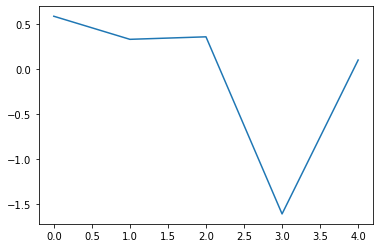

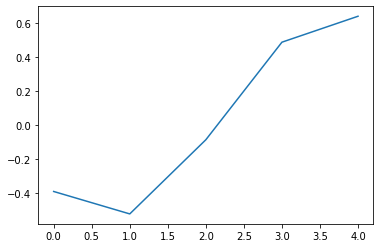

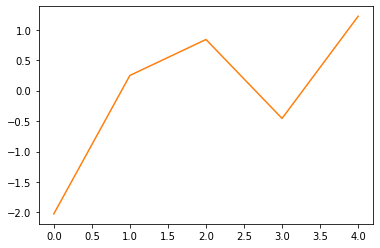

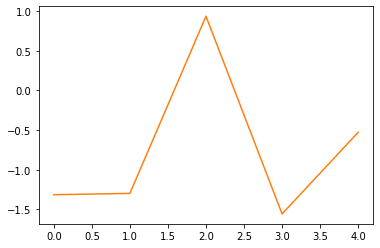

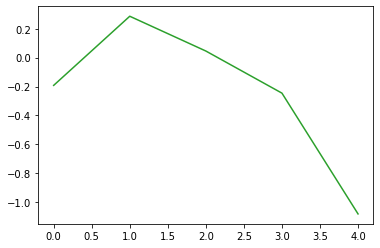

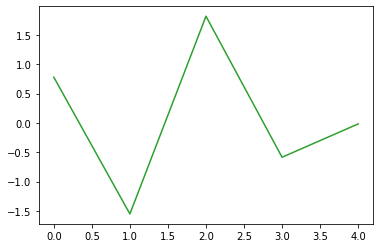

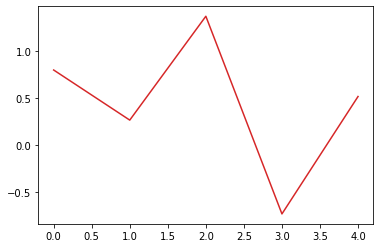

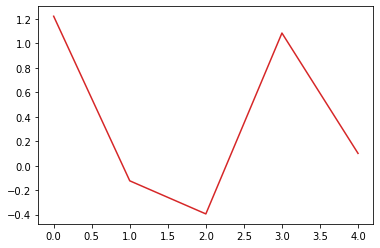

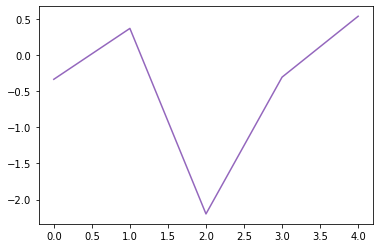

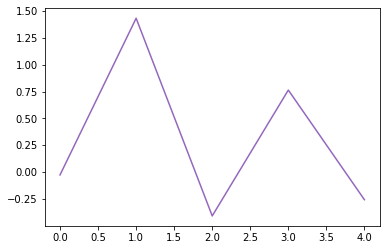

preY var 3.82162568067966
preY var 10.810521329161105
preY var 7.1663934494439925
preY var 4.099131605095934
preY var 7.5011875439788165
full_y var 31.09197423320164
final_y_probs
[[1.14174641e-05 9.99988583e-01]
 [9.57048857e-01 4.29511430e-02]
 [8.04690903e-07 9.99999195e-01]]
[[1.14174641e-05 1.00000000e+00]
 [9.57048857e-01 1.00000000e+00]
 [8.04690903e-07 1.00000000e+00]]
[[0.8032141 ]
 [0.1122232 ]
 [0.94165156]]
[1 0 1]
logloss 0.4209777909381705
entropyloss 0.16822250887071527
-1
0
1
2
3
4
5
6
7
8
9
~~~saved~~~


In [3]:

# N = 1000*1000
TRN_N = 1000*1000
TST_N = 10*1000
N = TRN_N + TST_N

# Ds = [10,30,50]
Ds = [10,20,30]
seeds=list(range(5))
Ds = [10]
seeds=list(range(1))

# MAX_TUPLES_PER_BAND = 300
# MAX_TUPLES_PER_BAND = 4  #04/16/2025 @ 6:00pm
# MAX_TUPLES_PER_BAND = 1  #04/16/2025 @ 6:20pm
# MAX_TUPLES_PER_BAND = 4  #04/16/2025 @ 7:40pm
# MAX_TUPLES_PER_BAND = { #04/16/2025 @ 11:50pm
#     1 : 4,
#     2 : 16,
#     3 : 64,
# }

I_k = 5
for D in Ds:
    for seed in seeds:
        np.random.seed(seed)
        synth_dataset_id = f"SYNTH_simple_synthwave_D{D}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_synthwave_v2_D{D}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_synthwave_v3_D{D}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_synthwave_v4_D{D}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_synthwave_v5_D{D}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_synthwave_v6_D{D}_seed{seed}"
        
        synth_dataset_id = f"SYNTH_simple_discrete_synthwave_v7_D{D}_Ik{I_k}_seed{seed}"
        synth_dataset_id = f"SYNTH_simple_discrete_synthwave_v8_D{D}_Ik{I_k}_seed{seed}"
        
        synth_dataset_id = "SYNTH_simple_multiclass_sparse_discrete_v1_"+f"D{D}_Ik{I_k}_seed{seed}"
        synth_dataset_id = "SYNTH_simple_multiclass_sparse_discrete_v2_"+f"D{D}_Ik{I_k}_seed{seed}"
        synth_dataset_id = "SYNTH_simple_multiclass_sparse_discrete_v3_"+f"D{D}_Ik{I_k}_seed{seed}"
        preproc_owner = None #TODO: check if this is fine
        print(synth_dataset_id)
        save_dataset_path = base_save_dataset_path + synth_dataset_id + "/"

        C = D #sparsity with each input contributing to an output class
        C = 2 #04/20/2025 -- v3
        singles = [(i,) for i in range(D)]
        pairs = list(combinations((range(D)),2))
        triples = list(combinations((range(D)),3))

#         # singles=singles[:MAX_TUPLES_PER_BAND]
#         # pairs=pairs[:MAX_TUPLES_PER_BAND]
#         # triples=triples[:MAX_TUPLES_PER_BAND]
#         singles=singles[:MAX_TUPLES_PER_BAND[1]]
#         pairs=pairs[:MAX_TUPLES_PER_BAND[2]]
#         triples=triples[:MAX_TUPLES_PER_BAND[3]]

#         all_indices = singles + pairs + triples
#         ###all_indices = [(0,), (1,2), (3,4,5),] #just checking
#         print(all_indices)
        
        all_indices = singles
        all_indices = singles[:5] #TRYING TO SEE SOMETHING IN ARCH



        # X = (np.random.rand(N,D)*2-1)*np.sqrt(3)
        # X = (np.random.rand(N,D)*2-1)*np.sqrt(1)
        # X = (np.random.rand(N,D)*2-1)*np.sqrt(4)

        X_int = np.random.randint(I_k,size=(N,D))
        print(X_int.shape)
        X_onehot = np.zeros((N,D*I_k),dtype=int)
        for d in range(D):
            X_onehot[np.arange(N),d*I_k+X_int[:,d]] = 1

        
        beta_dict = {}
        beta_power_bands = {}
        for K in range(3):
            beta_power_bands[K+1] = 0.0
        for tup in all_indices:
            # beta_tt = np.random.randn()
            # beta_dict[tup] = beta_tt
            # beta_power_bands[len(tup)] += beta_tt**2

            
            beta_tt = np.random.randn(*([I_k]*len(tup)+[C]))
            if False:
                beta_tt_c = np.random.randn(*([I_k]*len(tup)))
                beta_tt = np.zeros(tuple([I_k]*len(tup)+[C]))
                beta_tt[:,tup[0]] = beta_tt_c #each of 10 inputs only affect one of 10 classes
            beta_dict[tup] = beta_tt
            ############beta_power_bands[len(tup)] += beta_tt**2

            complete_semimasked_U = np.ones_like(beta_tt)
            complete_semimasked_U = complete_semimasked_U / np.sum(complete_semimasked_U) * C
            # print(complete_semimasked_U)

            purepower = list(powerset(tup))
            # residuals_dict = {}
            # residuals_dict[tup] = torch.zeros_like(theta_tt)


            # for ii in range(len(tup)):
            #     print(np.sum(beta_tt,axis=ii))
                
            currlen=len(tup)
            residual = 0.0
            if False: #ADJUSTING RESIDUAL TO BE ZERO CENTERED -- TURNING OFF FOR SPARSITY
                for purelen in range(currlen-1,-1,-1): 
                    for pp,puretup in enumerate(purepower):
                        if len(puretup)==purelen:
                            # print('puretup',puretup)
                            exttup1 = tuple( [(slice(None) if i in puretup else None) for i in tup] )
                            exttup2 = tuple( [(slice(None) if i not in puretup else None) for i in tup] )
                            axes_to_sum = tuple( [ii for ii,i in enumerate(tup) if i in puretup] )
                            axes_to_not_sum = tuple( [ii for ii,i in enumerate(tup) if i not in puretup] )

                            unflattened_U = np.sum(complete_semimasked_U, axis=axes_to_sum, keepdims=True)
                            unflattened_beta = np.sum(beta_tt, axis=axes_to_not_sum, keepdims=True)
                            beta_tt_pp = unflattened_beta * unflattened_U

                            sign = 0.0
                            if (purelen-currlen)%2 == 1:
                                sign = 1.0
                            else:
                                sign = -1.0

                            residual += sign * beta_tt_pp
            beta_tt_adjusted = beta_tt - residual
#             print('beta_tt',beta_tt)
#             print('beta_tt_adjusted',beta_tt_adjusted)
            beta_power_bands[len(tup)] += np.mean(beta_tt_adjusted**2)        
            beta_dict[tup] = beta_tt_adjusted


        if True: #plotting to see correlations in betas (which I think is affecting final archipelago)
#             for tt,tup in enumerate(all_indices):
#                 final_beta_tt = beta_dict[tup]
#                 for tt2 in range(C):
#                     plt.plot(np.arange(I_k),final_beta_tt[:,tt2],c="C"+str(tt))
#             plt.show()
            for tt,tup in enumerate(all_indices):
                final_beta_tt = beta_dict[tup]
                for tt2 in range(C):
                    plt.plot(np.arange(I_k),final_beta_tt[:,tt2],c="C"+str(tt))
                    plt.show()
        
        full_y = 0.0
        for tup in all_indices:
            ##final_beta_tt = beta_dict[tup] / np.sqrt(beta_power_bands[len(tup)]) / np.sqrt(3.)
            final_beta_tt = beta_dict[tup] 
            final_beta_tt = beta_dict[tup] * 3.0 #04/19/2025 @ 10:30pm
            

            # preY = np.zeros(X.shape[0])
            preY = np.zeros((N,C))
            for i_tup in product(*([list(range(I_k))]*len(tup))):
                #print(i_tup)

                
                inds = np.ones(N,dtype=bool)
                # print(inds[:10])
                for kk,k in enumerate(tup):
                    # print(np.any(X[:,k]==i_tup[kk]))
                    # inds = np.logical_and(inds, X[:,k]==i_tup[kk])
                    inds = np.logical_and(inds, X_onehot[:,I_k*k+i_tup[kk]]==1)
                    # print(inds[:10])
                # print(inds.shape)
                preY[inds] += final_beta_tt[i_tup]
                # print('\tpreY','var',np.var(preY))

            # # plt.scatter(X_onehot[-TST_N:,tup[0]],preY[-TST_N:])
            # plt.scatter(np.matmul(X_onehot[-TST_N:,tup[0]*I_k:tup[0]*I_k+I_k],np.arange(I_k)),preY[-TST_N:])
            # plt.show()

            ###full_y += final_beta_tt * preY
            print('preY','var',np.var(preY))
#             print('preY','mse',np.mean(preY**2))
            full_y +=  preY
#             print('full_y','var',np.var(full_y))
        print('full_y','var',np.var(full_y))
        
        from scipy.special import log_softmax
        final_y_logprobs = log_softmax(full_y, axis=-1)
        final_y_probs = np.exp(final_y_logprobs)
        final_y_cumprobs = np.cumsum(final_y_probs, axis=-1)
        selection_noise = np.random.rand(N)[:,None]
        xd = np.sum((selection_noise>=final_y_cumprobs),axis=1)
        print('final_y_probs')
        print(final_y_probs[:3])
        print(final_y_cumprobs[:3])
        print(selection_noise[:3])
        print(xd[:3])
        onehot_y = np.zeros((N,C),dtype=int)
        onehot_y[np.arange(N),xd] = 1
#         print(onehot_y[:3])
        
        if True: #calculate semi-empirical best log loss
            best_y_hat = np.argmax(final_y_probs,axis=-1)
            onehot_y_hat = np.ones((N,C),dtype=int) * 0.01
            onehot_y_hat[np.arange(N),best_y_hat] = 0.91
            logloss = np.sum(-final_y_probs*np.log(onehot_y_hat),axis=-1)
            logloss = np.mean(logloss)
            print('logloss',logloss)
            entropyloss = np.sum(-final_y_probs*np.log(final_y_probs),axis=-1)
            entropyloss = np.mean(entropyloss)
            print('entropyloss',entropyloss)
        
        
        
        ### ACTUAL SAVING STUFF

        readable_labels = {}
        full_readable_labels = {}
        startdim = 0
#         for d in range(D):
        for d in range(-1,D):
            full_info_d = {
                "label" : "X"+str(d+1),
                "startdim" : d*I_k,
                "numdims" : I_k,
                "encoding" : "disc.onehot",
            }
            if d==-1:
#                 full_info_d = {
#                     "label" : "Y",
#                     "startdim" : 0,
#                     "numdims" : C,
#                     "encoding" : "disc.onehot",
#                     "count" : C,
#                 }
                full_info_d = {"label" : "Y",
                    "startdim" : 0, "numdims" : 1,
                    "encoding" : "disc.ordinal", "type" : "disc.ordinal",
                    "min" : 0, "count" : 2,
                }
            print(d)
            readable_labels[d] = full_info_d["label"]
            full_readable_labels[d] = full_info_d
        full_readable_labels["task_type"] = "binary_classification"
        full_readable_labels["D0"] = D
        full_readable_labels["D"] = D
        
        
        fake_header_dict = {
            "Preprocessed Datetime" : datetimestr, 
            "dataset_id" : synth_dataset_id,
            "preproc_owner" : preproc_owner,

            #"load_dataset_path" : load_dataset_path,
            "save_dataset_path" : save_dataset_path,
        }

        trainval_portion, is_test_split_shuffled, shuffle_test_split_seed = None, False, None
        if trainval_portion is None:
            trainval_portion = 0.80
            trainval_portion = TRN_N/N
            assert int(trainval_portion*N)==TRN_N
        fake_header_dict["is_test_split_shuffled"]  = is_test_split_shuffled
        fake_header_dict["shuffle_test_split_seed"] = shuffle_test_split_seed
        fake_header_dict["trainval_portion"]        = trainval_portion
        
        fake_header_dict["datagen_seed"] = seed

        #######label_stuff = (full_readable_labels, datatype_labels, full_readable_labels)
        label_stuff = (readable_labels, full_readable_labels)    
        label_dict = {
            "readable_labels" : label_stuff[0],
            "full_readable_labels" : label_stuff[1],
        }

        if True:
            fullX=X_onehot; fullY=xd;
            final_save_header(save_dataset_path, fake_header_dict)
            trnvalX,trnvalY,tstX,tstY = final_save_dataset(save_dataset_path, fullX, fullY, 
                                                            trainval_portion, is_test_split_shuffled, shuffle_test_split_seed)

            ''' asdf asdf asdf '''
            ### #### #### #### ###
#             final_save_labels(save_dataset_path, *label_stuff)
            final_save_labels(save_dataset_path, label_dict)
        print("~~~saved~~~")